## Análise Univariada

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

df = pd.read_csv('../dados/taylor_swift_limpo.csv')
features_continuas = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms'
]

### Resumo estatístico

In [ ]:
display(df[features_continuas].describe().T[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
danceability,0.585454,0.115011,0.292000,0.5980,0.897
energy,0.559528,0.176609,0.151000,0.5630,0.916
loudness,-7.877354,2.655783,-15.512000,-7.6100,-1.927
speechiness,0.058466,0.057149,0.025000,0.0403,0.519
acousticness,0.350880,0.326550,0.000191,0.2200,0.971
instrumentalness,0.003247,0.027204,0.000000,0.0000,0.333
liveness,0.136576,0.077519,0.039100,0.1120,0.596
valence,0.393987,0.187951,0.038400,0.3800,0.920
duration_ms,236827.157205,47420.272884,131907.000000,232253.0000,613026.000


### Histogramas e Distribuição

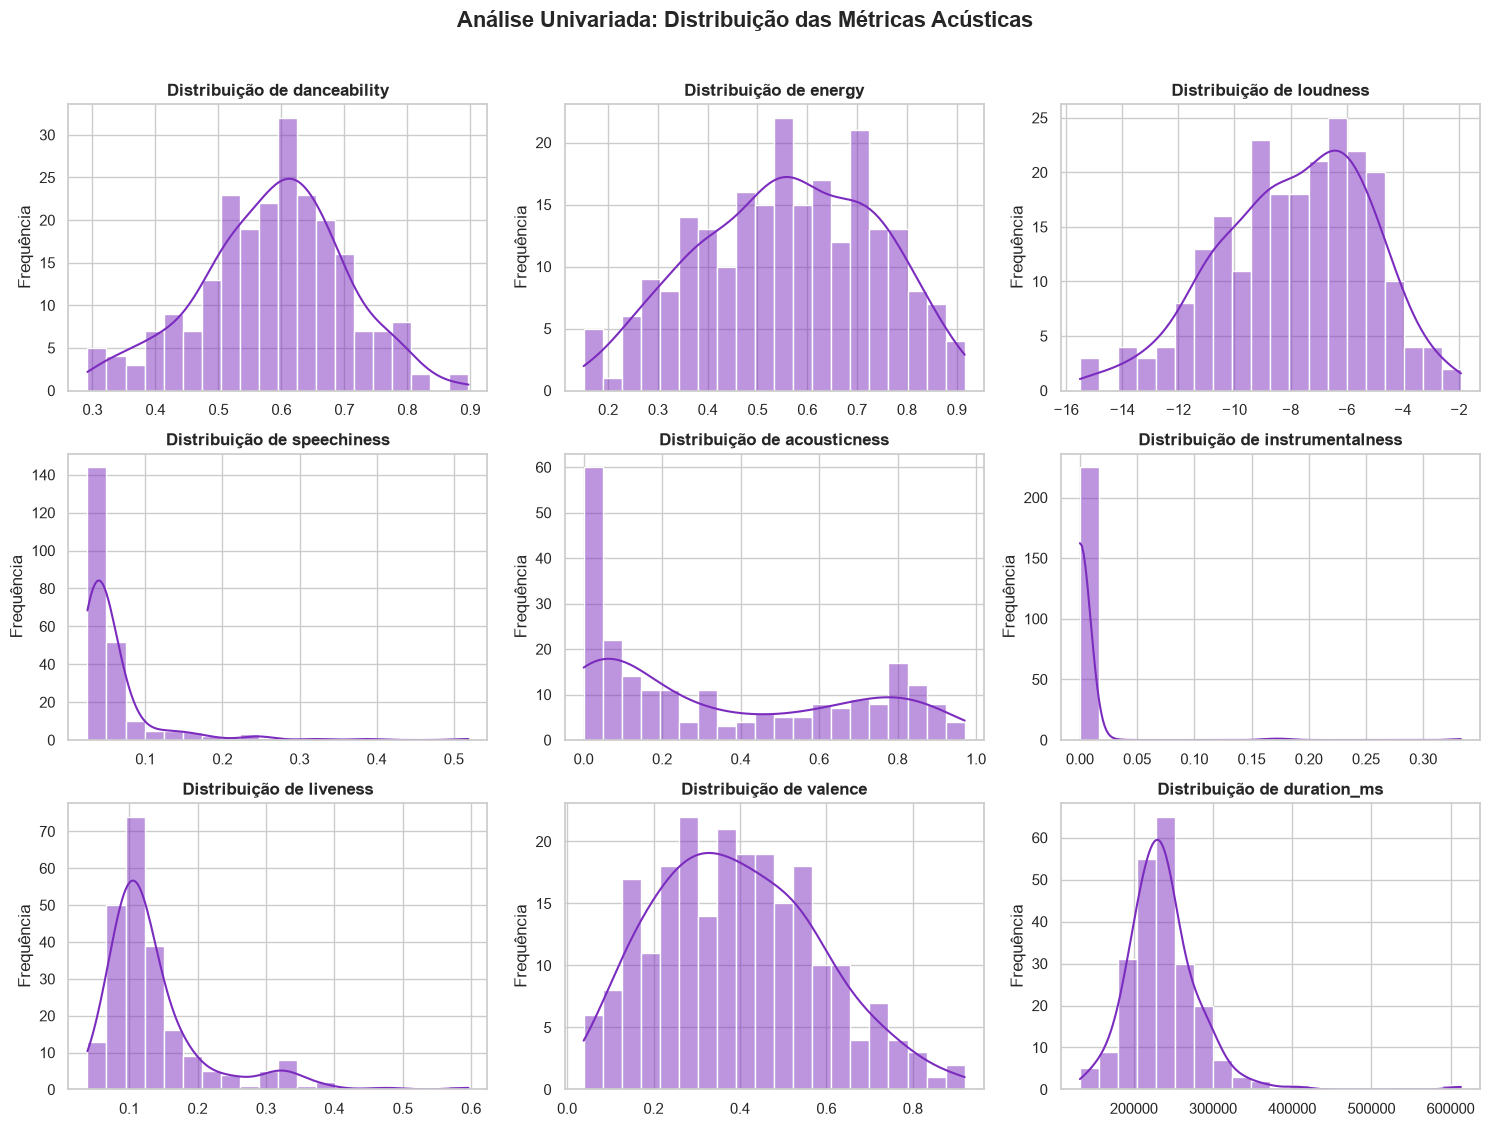

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#7b2cbf', bins=20)
    axes[i].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Análise Univariada: Distribuição das Métricas Acústicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Boxplots

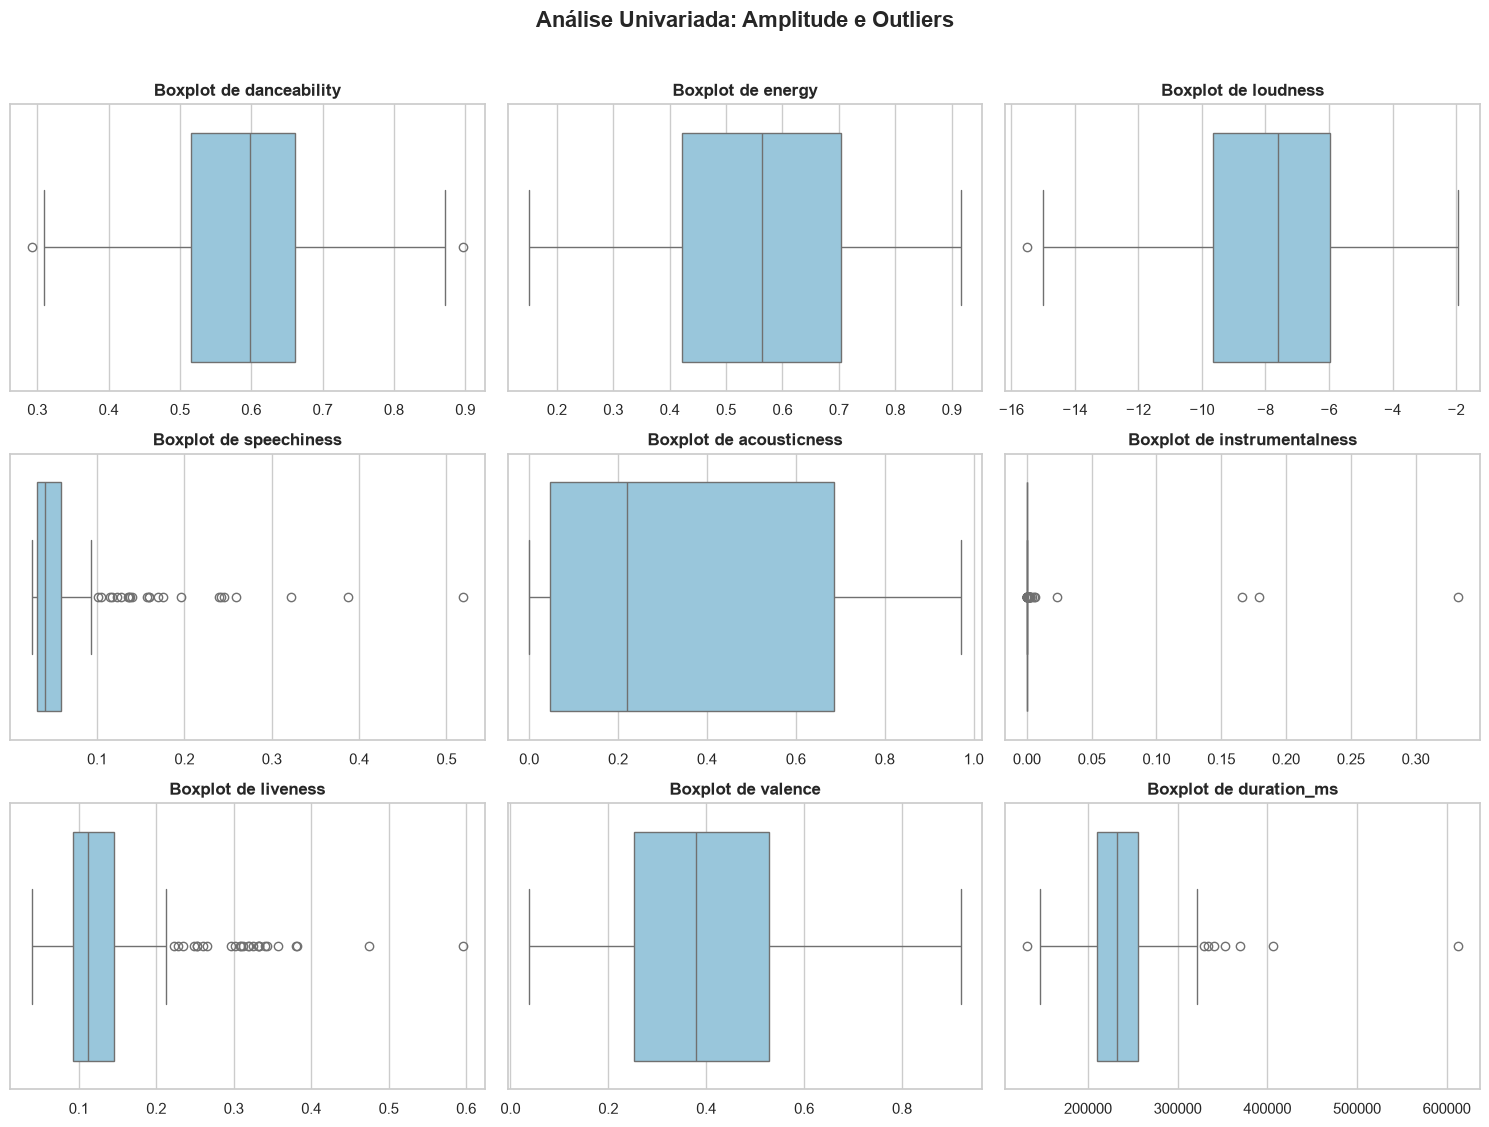

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    sns.boxplot(x=df[col], ax=axes[i], color='#8ecae6')
    axes[i].set_title(f'Boxplot de {col}', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Análise Univariada: Amplitude e Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Total de músicas e faixas explícitas

C:\Users\Master\AppData\Local\Temp\ipykernel_11132\2677486919.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Clean', 'Explicit'])


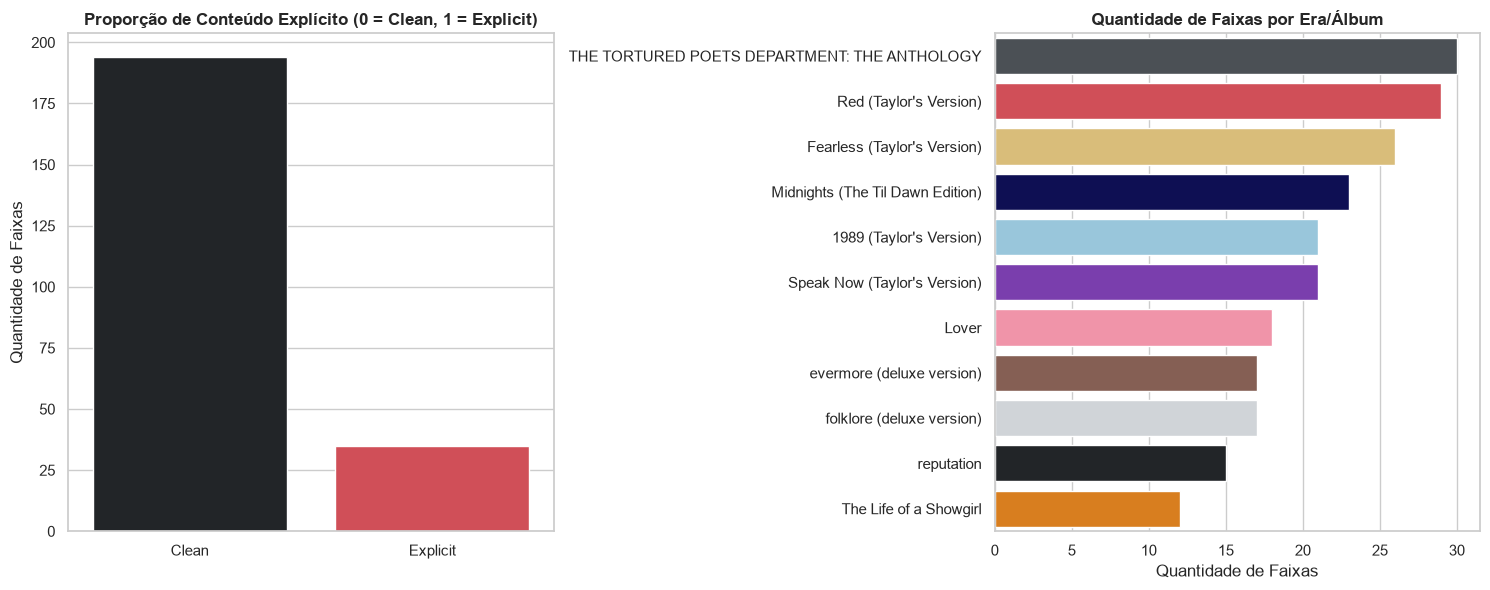

In [ ]:
ordem_albuns = [
    'Taylor Swift', 
    "Fearless (Taylor's Version)", 
    "Speak Now (Taylor's Version)",
    "Red (Taylor's Version)",
    "1989 (Taylor's Version)",
    "reputation",
    "Lover",
    "folklore (deluxe version)",
    "evermore (deluxe version)",
    "Midnights (The Til Dawn Edition)",
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY",
    "The Life of a Showgirl"
]

cores_eras = [
    '#2b9348', 
    '#e9c46a', 
    '#7b2cbf',  
    '#e63946',  
    '#8ecae6',  
    '#212529', 
    '#ff85a1',  
    '#ced4da', 
    '#8d5b4c',  
    '#03045e',  
    '#495057',  
    '#f77f00'   
]

palette_dict = dict(zip(ordem_albuns, cores_eras))
ordem_quantidade = df['album_name'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(
    data=df, 
    x='explicit', 
    ax=axes[0], 
    palette=['#212529', '#e63946'],
    hue='explicit',
    legend=False
)
axes[0].set_title('Proporção de Conteúdo Explícito (0 = Clean, 1 = Explicit)', fontweight='bold')
axes[0].set_xticklabels(['Clean', 'Explicit'])
axes[0].set_ylabel('Quantidade de Faixas')
axes[0].set_xlabel('')

sns.countplot(
    data=df, 
    y='album_name', 
    ax=axes[1], 
    order=ordem_quantidade, 
    palette=palette_dict,
    hue='album_name',
    legend=False
)
axes[1].set_title('Quantidade de Faixas por Era/Álbum', fontweight='bold')
axes[1].set_xlabel('Quantidade de Faixas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

##  Conclusão da Análise Univariada
A análise univariada das métricas acústicas e metadados das 12 eras da Taylor Swift permitiu mapear o perfil individual das variáveis, fornecendo diagnósticos essenciais para a interpretação de negócio e decisões de modelagem:

###  Principais Achados
1. **Comportamento das Métricas Contínuas:**
   * **Gaussianas/Simétricas:** Variaveis como `danceability`, `energy`, `loudness` e `valence` apresentam distribuições bem balanceadas ao longo do catálogo, refletindo a versatilidade pop da artista, com médias moderadas a altas de energia e dançabilidade.
   * **Bimodalidade em `acousticness`:** A distribuição apresenta picos distintos em valores próximos de $0.0$ e $0.8$. Isso marca claramente o contraste entre a produção eufórica/synth-pop de eras como *1989* e *reputation* e os arranjos predominantemente acústicos das eras *folklore* e *evermore*.

2. **Assimetria e Outliers Reais:**
   * Métricas como `speechiness`, `instrumentalness` e `liveness` possuem forte assimetria positiva (concentradas perto de 0). 
   * A ausência quase total de `instrumentalness` é condizente com um repertório focado em vocal/composição. Os *outliers* observados em `duration_ms` (como a versão de 10 minutos de *"All Too Well"*) e `speechiness` representam trechos falados ou faixas estendidas legítimas do catálogo, e não ruídos de captura.

3. **Conteúdo Explícito e Volume por Era:**
   * A proporção de faixas com selo `explicit` é minoritária e concentrada fortemente do álbum *folklore* em diante.
   * Existe um desbalanceamento no volume de faixas por classe (álbum), impulsionado por lançamentos do tipo *Anthology* e edições *Taylor's Version* (com faixas *From The Vault*).